# Data Science I
<div style="position: relative;">
    <div style="position: absolute; top: -60px; right: 10px; padding: 5px; background-color: transparent; font-size: 20px; text-align: right;">
        <span>Version: October 10, 2025</span>
    </div>
</div>

## Project Report: Predicting Energy Prices
<span style="font-weight: bold; text-decoration: underline;">Submission Deadline: January 25 2026, 21:00 UTC</span>
    
**University of Oldenburg**<br/>
**Winter 2025/2026**<br/>
**Instructors**: [Jannik Schröder](https://uol.de/team-data/jannik-schroeder), [Wolfram "Wolle" Wingerath](https://uol.de/wolle)

<span style="font-weight: bold; ">Submitted by: <span style="color: red;">&lt;Aysel Abdullayeva, Tsolmon Erdenebayar&gt;</span>

---

<h2>Phase 1: Gathering Domain Knowledge &amp; Data Sources</h2>
<div style="position: relative;">
    <div style="position: absolute; top: -40px; right: 10px; padding: 5px; background-color: #ddd; border-radius: 5px; font-size: 20px; border: 1px solid black; text-align: right;">
        <span style="">&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; / 25</span>
    </div>
</div>

#### 1.1 Research the energy market's structure, including how prices are set and the role of different energy sources.

Germany’s wholesale electricity market is part of the integrated European market. For this project, the key segment is the **day-ahead market**, where electricity for tomorrow is traded in a daily auction. Because electricity must be balanced in real time and storage is limited, prices react quickly to changes in demand, renewable output, and available conventional generation.  
In the day-ahead auction, participants submit buy and sell bids for each hour of the next day. The exchange aggregates bids into supply and demand curves and clears the market at their intersection. Price formation follows **marginal pricing**: generators are dispatched by increasing marginal cost (the “merit order”), and the most expensive unit still needed to meet demand becomes the **marginal plant** and sets the clearing price.  
Energy sources matter mainly through marginal cost and controllability. **Wind and solar** have very low marginal costs, so higher forecast output typically shifts supply outward and lowers prices (merit-order effect). When renewable output is very high relative to demand and inflexible generation cannot reduce output easily, prices can become very low or even negative. **Dispatchable thermal plants** (gas, coal, lignite) fill gaps when renewables are low; their marginal costs depend on fuel and CO₂ prices, and they often set the price in tight hours. **Imports/exports** also influence the clearing price when interconnector capacity allows cross-border trading.  
This logic motivates the core predictors used later: demand (load), weather-driven renewable supply (wind/solar), and their combination as **residual load**.

#### 1.2 Understand regulatory policies, market reforms, and technological advancements that could impact energy prices.

A major structural driver of marginal generation costs is the **EU Emissions Trading System (EU ETS)**. Fossil generators must buy CO₂ allowances, which raises marginal costs, especially for coal and lignite, and can lift day-ahead prices when fossil units are on the margin.  
Germany’s renewable expansion has increased the share of low-marginal-cost generation, pushing prices down in windy/sunny hours while increasing variability when renewables drop and dispatchable plants are needed. At the same time, policy decisions on the conventional fleet changed the system. The **nuclear phase-out (completed 2023)** removed low-marginal-cost baseload capacity and increased the importance of flexible generation, imports, and balancing options.  
European **market coupling** links day-ahead markets, improving efficiency and allowing prices to converge when transmission capacity is available, but it also means shocks can spread across borders. Technology trends also matter: storage growth can reduce extremes by shifting energy between hours, while electrification (EVs, heat pumps) changes demand levels and load profiles.  
For this project, the key practical point is the **2022 energy crisis**, which created a clear regime shift with much higher prices and volatility. Models should be evaluated with this structural break in mind.

#### 1.3 Review energy sector publications, expert analyses, and videos or other resources.

The main data source is **SMARD.de**, which provides German day-ahead prices and forecast series for load and renewable generation. For broader context and cross-checks, the **ENTSO-E Transparency Platform** is a standard European reference for generation, load, and cross-border flows. To understand auction mechanics and price setting, exchange documentation such as **EPEX SPOT** materials is useful.  
For interpretation of the energy transition and the merit-order/residual-load concept, analyses from **Fraunhofer ISE** (Energy-Charts and reports) and **Agora Energiewende** provide clear explanations and figures. International sources such as the **IEA** and groups like **Ember** help contextualize fuel-price shocks and structural changes. Short lectures/explainers from TSOs, exchanges, and research institutes helped clarify why negative prices and spikes occur and why forecasts of wind/solar and demand are central for day-ahead prediction.

*Sources:*
- *Agora Energiewende – reports and analyses*  
- *Bundesnetzagentur (BNetzA) – Energy / Electricity market information*  
- *Ember – European power sector analysis and data*  
- *ENTSO-E Transparency Platform*  
- *EPEX SPOT (Day-Ahead market information)*  
- *European Commission – EU Emissions Trading System (EU ETS)*  
- *Federal Ministry for Economic Affairs and Climate Action (BMWK, Germany)*  
- *Fraunhofer ISE – Energy-Charts and related publications*  
- *International Energy Agency (IEA) – Germany energy publications*  
- *SMARD (Bundesnetzagentur)*

<h2>Phase 2: Data Cleaning &amp; Exploratory Data Analysis (EDA)</h2>
<div style="position: relative;">
    <div style="position: absolute; top: -40px; right: 10px; padding: 5px; background-color: #ddd; border-radius: 5px; font-size: 20px; border: 1px solid black; text-align: right;">
        <span style="">&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; / 25</span>
    </div>
</div>

#### 2.1 Prepare your data for analysis by handling missing values, outliers, and ensuring data quality.

In [3]:
# Libraries
import numpy as np
import pandas as pd

import os

import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# -----------------------------
# 2.1.1 Clean and export: Day-ahead price, Forecasted consumption (grid load)
# & Day-ahead forecasted generation (wind/solar)
# -----------------------------

# Day-ahead price, hourly (SMARD export)
price_raw = pd.read_csv(
    "data/raw/Day-ahead_prices_202101010000_202601010000_Hour.csv",
    sep=";",
    decimal=","
)

# Keep target series and rename to a short, consistent column name
price = (
    price_raw[["Start date", "Germany/Luxembourg [€/MWh] Calculated resolutions"]]
    .copy()
    .rename(columns={
        "Start date": "timestamp_local",
        "Germany/Luxembourg [€/MWh] Calculated resolutions": "price_eur_mwh"
    })
)

# SMARD timestamps are in market time (Europe/Berlin); convert to UTC for a continuous hourly index
price["timestamp_local"] = pd.to_datetime(
    price["timestamp_local"],
    format="%b %d, %Y %I:%M %p",
    errors="coerce"
)
price["timestamp"] = (
    price["timestamp_local"]
    .dt.tz_localize("Europe/Berlin", ambiguous="infer", nonexistent="shift_forward")
    .dt.tz_convert("UTC")
)

# Set timestamp index (useful for merging with other hourly series)
price = price.drop(columns=["timestamp_local"]).set_index("timestamp").sort_index()

# Sanity checks
print("Time range (UTC):", price.index.min(), "to", price.index.max())
print("Rows:", len(price))
print("Duplicate timestamps:", price.index.duplicated().sum())
print("Missing prices:", price["price_eur_mwh"].isna().sum())

# Save cleaned series
os.makedirs("data/processed", exist_ok=True)
price.reset_index().to_csv("data/processed/price_utc.csv", index=False)

Time range (UTC): 2020-12-31 23:00:00+00:00 to 2025-12-31 22:00:00+00:00
Rows: 43824
Duplicate timestamps: 0
Missing prices: 0


In [5]:
# Forecasted electricity consumption (grid load), hourly (SMARD export)
cons_raw = pd.read_csv(
    "data/raw/Forecasted_consumption_202101010000_202601010000_Hour.csv",
    sep=";",
    decimal=","
)

# Keep series and rename to a short, consistent column name
cons = (
    cons_raw[["Start date", "grid load [MWh] Calculated resolutions"]]
    .copy()
    .rename(columns={
        "Start date": "timestamp_local",
        "grid load [MWh] Calculated resolutions": "load_mwh"
    })
)

# Convert SMARD market time (Europe/Berlin) to UTC
cons["timestamp_local"] = pd.to_datetime(
    cons["timestamp_local"],
    format="%b %d, %Y %I:%M %p",
    errors="coerce"
)
cons["timestamp"] = (
    cons["timestamp_local"]
    .dt.tz_localize("Europe/Berlin", ambiguous="infer", nonexistent="shift_forward")
    .dt.tz_convert("UTC")
)

# Ensure numeric values (in case SMARD uses thousands separators)
cons["load_mwh"] = pd.to_numeric(cons["load_mwh"].astype(str).str.replace(",", ""), errors="coerce")

# Set timestamp index for later merges
cons = cons.drop(columns=["timestamp_local"]).set_index("timestamp").sort_index()

# Sanity checks
print("Time range (UTC):", cons.index.min(), "to", cons.index.max())
print("Rows:", len(cons))
print("Duplicate timestamps:", cons.index.duplicated().sum())
print("Missing load values:", cons["load_mwh"].isna().sum())

# Save cleaned series
cons.reset_index().to_csv("data/processed/load_forecast_utc.csv", index=False)

Time range (UTC): 2020-12-31 23:00:00+00:00 to 2025-12-31 22:00:00+00:00
Rows: 43824
Duplicate timestamps: 0
Missing load values: 0


In [6]:
# Day-ahead forecasted generation (wind/solar), hourly (SMARD export)
gen_raw = pd.read_csv(
    "data/raw/Forecasted_generation_Day-Ahead_202101010000_202601010000_Hour.csv",
    sep=";",
    decimal=","
)

# Keep wind/solar forecasts and rename to short, consistent column names
gen = (
    gen_raw[[
        "Start date",
        "Wind offshore [MWh] Calculated resolutions",
        "Wind onshore [MWh] Calculated resolutions",
        "Photovoltaics [MWh] Calculated resolutions",
    ]]
    .copy()
    .rename(columns={
        "Start date": "timestamp_local",
        "Wind offshore [MWh] Calculated resolutions": "wind_offshore_mwh",
        "Wind onshore [MWh] Calculated resolutions": "wind_onshore_mwh",
        "Photovoltaics [MWh] Calculated resolutions": "solar_mwh",
    })
)

# Convert SMARD market time (Europe/Berlin) to UTC
gen["timestamp_local"] = pd.to_datetime(
    gen["timestamp_local"],
    format="%b %d, %Y %I:%M %p",
    errors="coerce"
)
gen["timestamp"] = (
    gen["timestamp_local"]
    .dt.tz_localize("Europe/Berlin", ambiguous="infer", nonexistent="shift_forward")
    .dt.tz_convert("UTC")
)

# Ensure numeric values
for c in ["wind_offshore_mwh", "wind_onshore_mwh", "solar_mwh"]:
    gen[c] = pd.to_numeric(gen[c].astype(str).str.replace(",", ""), errors="coerce")

# Set timestamp index for later merges
gen = gen.drop(columns=["timestamp_local"]).set_index("timestamp").sort_index()

# Sanity checks
print("Time range (UTC):", gen.index.min(), "to", gen.index.max())
print("Rows:", len(gen))
print("Duplicate timestamps:", gen.index.duplicated().sum())
print("Missing values:", gen.isna().sum().to_dict())

# Save cleaned series
gen.reset_index().to_csv("data/processed/generation_forecast_utc.csv", index=False)

Time range (UTC): 2020-12-31 23:00:00+00:00 to 2025-12-31 22:00:00+00:00
Rows: 43824
Duplicate timestamps: 0
Missing values: {'wind_offshore_mwh': 0, 'wind_onshore_mwh': 0, 'solar_mwh': 0}


In [7]:
# -----------------------------
# 2.1.2 Merge cleaned series into one hourly table
# -----------------------------

price_df = pd.read_csv("data/processed/price_utc.csv", parse_dates=["timestamp"])
load_df  = pd.read_csv("data/processed/load_forecast_utc.csv", parse_dates=["timestamp"])
gen_df   = pd.read_csv("data/processed/generation_forecast_utc.csv", parse_dates=["timestamp"])

# Ensure timezone-aware UTC timestamps after reading CSV
for df in (price_df, load_df, gen_df):
    df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)

# Inner join: keep only hours available in all series
data = (
    price_df
    .merge(load_df, on="timestamp", how="inner")
    .merge(gen_df, on="timestamp", how="inner")
    .sort_values("timestamp")
    .reset_index(drop=True)
)

print("Merged rows:", len(data))
print("Merged time range (UTC):", data["timestamp"].min(), "to", data["timestamp"].max())
print("Missing values per column:", data.isna().sum().to_dict())

data.head()

Merged rows: 43824
Merged time range (UTC): 2020-12-31 23:00:00+00:00 to 2025-12-31 22:00:00+00:00
Missing values per column: {'timestamp': 0, 'price_eur_mwh': 0, 'load_mwh': 0, 'wind_offshore_mwh': 0, 'wind_onshore_mwh': 0, 'solar_mwh': 0}


,timestamp,price_eur_mwh,load_mwh,wind_offshore_mwh,wind_onshore_mwh,solar_mwh
0,2020-12-31 23:00:00+00:00,50.87,43156.25,531.25,4102.25,0.0
1,2021-01-01 00:00:00+00:00,48.19,41599.25,464.75,3653.75,0.0
2,2021-01-01 01:00:00+00:00,44.68,40513.50,426.00,3218.00,0.0
3,2021-01-01 02:00:00+00:00,42.92,40148.00,398.25,2867.75,0.0
4,2021-01-01 03:00:00+00:00,40.39,39846.75,377.00,2617.00,0.0


In [8]:
# -----------------------------
# 2.1.3 Feature engineering for modeling (day-ahead setting)
# -----------------------------

# Core derived fundamentals
data["wind_total_mwh"] = data["wind_offshore_mwh"] + data["wind_onshore_mwh"]
data["residual_load_mwh"] = data["load_mwh"] - (data["wind_total_mwh"] + data["solar_mwh"])

# Lag features capturing daily/weekly seasonality (common in electricity price forecasting)
data["price_lag_24"] = data["price_eur_mwh"].shift(24)
data["price_lag_168"] = data["price_eur_mwh"].shift(168)
data["residual_load_lag_24"] = data["residual_load_mwh"].shift(24)
data["residual_load_lag_168"] = data["residual_load_mwh"].shift(168)

# Calendar features (UTC)
ts = data["timestamp"]
data["hour"] = ts.dt.hour
data["day_of_week"] = ts.dt.dayofweek  # Monday=0 ... Sunday=6
data["month"] = ts.dt.month
data["is_weekend"] = (data["day_of_week"] >= 5).astype(int)

# Final modeling table (drop initial rows with missing lags)
cols = [
    "timestamp",
    "price_eur_mwh",
    "load_mwh",
    "wind_offshore_mwh", "wind_onshore_mwh", "wind_total_mwh",
    "solar_mwh",
    "residual_load_mwh",
    "price_lag_24", "price_lag_168",
    "residual_load_lag_24", "residual_load_lag_168",
    "hour", "day_of_week", "month", "is_weekend",
]
data_model = data[cols].dropna().reset_index(drop=True)

print("Rows before dropna:", len(data))
print("Rows after dropna:", len(data_model))
print("Time range after dropna (UTC):", data_model["timestamp"].min(), "to", data_model["timestamp"].max())

# Save final dataset for modeling
data_model.to_csv("data/processed/features_smard_utc.csv", index=False)

data_model.head()

Rows before dropna: 43824
Rows after dropna: 43656
Time range after dropna (UTC): 2021-01-07 23:00:00+00:00 to 2025-12-31 22:00:00+00:00


,timestamp,price_eur_mwh,load_mwh,wind_offshore_mwh,wind_onshore_mwh,wind_total_mwh,solar_mwh,residual_load_mwh,price_lag_24,price_lag_168,residual_load_lag_24,residual_load_lag_168,hour,day_of_week,month,is_weekend
0,2021-01-07 23:00:00+00:00,50.53,48253.25,1052.50,6426.00,7478.50,0.0,40774.75,51.03,50.87,39975.25,38522.75,23,3,1,0
1,2021-01-08 00:00:00+00:00,48.43,46315.75,1141.75,6333.50,7475.25,0.0,38840.50,50.18,48.19,37906.75,37480.75,0,4,1,0
2,2021-01-08 01:00:00+00:00,47.24,45664.25,1161.25,6258.50,7419.75,0.0,38244.50,48.97,44.68,37313.75,36869.50,1,4,1,0
3,2021-01-08 02:00:00+00:00,45.61,46053.25,1204.00,6212.25,7416.25,0.0,38637.00,46.72,42.92,37469.75,36882.00,2,4,1,0
4,2021-01-08 03:00:00+00:00,46.81,47048.75,1290.00,6122.00,7412.00,0.0,39636.75,46.87,40.39,38704.00,36852.75,3,4,1,0


**Final variables:**  
Time
- timestamp — hourly timestamp in UTC  

Target
- price_eur_mwh — day-ahead electricity price for Germany/Luxembourg (€/MWh)
- Forecast fundamentals (SMARD day-ahead forecasts)
- load_mwh — forecasted grid load / electricity consumption (MWh)
- wind_offshore_mwh — forecasted offshore wind generation (MWh)
- wind_onshore_mwh — forecasted onshore wind generation (MWh)
- solar_mwh — forecasted photovoltaic generation (MWh)  

Derived fundamentals
- wind_total_mwh — total wind forecast (wind_offshore_mwh + wind_onshore_mwh)
- residual_load_mwh — net load after wind and solar (load_mwh − (wind_total_mwh + solar_mwh))
- Lag features (seasonality)
- price_lag_24 — price 24 hours earlier (t−24)
- price_lag_168 — price 168 hours earlier (t−168)
- residual_load_lag_24 — residual load 24 hours earlier (t−24)
- residual_load_lag_168 — residual load 168 hours earlier (t−168)  

Calendar features (UTC-based)
- hour — hour of day (0–23)
- day_of_week — day of week (Mon=0 … Sun=6)
- month — month (1–12)
- is_weekend — weekend indicator (Sat/Sun = 1)

#### 2.2 Use statistical summaries and visualizations to understand the basic characteristics of the data. Explore the distribution of key variables and identify patterns or anomalies.

In [9]:
# -----------------------------
# 2.2.1 Load processed data + sanity snapshot
# -----------------------------
DATA_PATH = "data/processed/features_smard_utc.csv"

df = pd.read_csv(DATA_PATH, parse_dates=["timestamp"])

# Ensure timezone-aware UTC timestamps
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)

# Basic snapshot
print("Shape:", df.shape)
print("Time range (UTC):", df["timestamp"].min(), "to", df["timestamp"].max())
print("\nColumns:", df.columns.tolist())

# Data types + missing values
print("\nDtypes:\n", df.dtypes)
missing = df.isna().sum().sort_values(ascending=False)
print("\nMissing values per column:\n", missing[missing > 0] if (missing > 0).any() else "No missing values.")

# Quick check for duplicate timestamps
dup_ts = df["timestamp"].duplicated().sum()
print("\nDuplicate timestamps:", dup_ts)

df.head()

Shape: (43656, 16)
Time range (UTC): 2021-01-07 23:00:00+00:00 to 2025-12-31 22:00:00+00:00

Columns: ['timestamp', 'price_eur_mwh', 'load_mwh', 'wind_offshore_mwh', 'wind_onshore_mwh', 'wind_total_mwh', 'solar_mwh', 'residual_load_mwh', 'price_lag_24', 'price_lag_168', 'residual_load_lag_24', 'residual_load_lag_168', 'hour', 'day_of_week', 'month', 'is_weekend']

Dtypes:
 timestamp                datetime64[ns, UTC]
price_eur_mwh                        float64
load_mwh                             float64
wind_offshore_mwh                    float64
wind_onshore_mwh                     float64
wind_total_mwh                       float64
solar_mwh                            float64
residual_load_mwh                    float64
price_lag_24                         float64
price_lag_168                        float64
residual_load_lag_24                 float64
residual_load_lag_168                float64
hour                                   int64
day_of_week                            

,timestamp,price_eur_mwh,load_mwh,wind_offshore_mwh,wind_onshore_mwh,wind_total_mwh,solar_mwh,residual_load_mwh,price_lag_24,price_lag_168,residual_load_lag_24,residual_load_lag_168,hour,day_of_week,month,is_weekend
0,2021-01-07 23:00:00+00:00,50.53,48253.25,1052.50,6426.00,7478.50,0.0,40774.75,51.03,50.87,39975.25,38522.75,23,3,1,0
1,2021-01-08 00:00:00+00:00,48.43,46315.75,1141.75,6333.50,7475.25,0.0,38840.50,50.18,48.19,37906.75,37480.75,0,4,1,0
2,2021-01-08 01:00:00+00:00,47.24,45664.25,1161.25,6258.50,7419.75,0.0,38244.50,48.97,44.68,37313.75,36869.50,1,4,1,0
3,2021-01-08 02:00:00+00:00,45.61,46053.25,1204.00,6212.25,7416.25,0.0,38637.00,46.72,42.92,37469.75,36882.00,2,4,1,0
4,2021-01-08 03:00:00+00:00,46.81,47048.75,1290.00,6122.00,7412.00,0.0,39636.75,46.87,40.39,38704.00,36852.75,3,4,1,0


In [10]:
# -----------------------------
# 2.2.2 Descriptive statistics + simple anomaly counters
# -----------------------------

core = ["price_eur_mwh", "load_mwh", "wind_total_mwh", "solar_mwh", "residual_load_mwh"]

# Standard summary
desc = df[core].describe().T
print("Descriptive statistics:\n")
display(desc)

# More informative quantiles (for heavy-tailed price distributions)
q = df[core].quantile([0.01, 0.05, 0.50, 0.95, 0.99]).T
q.columns = ["q01", "q05", "q50", "q95", "q99"]
print("\nSelected quantiles (1%, 5%, 50%, 95%, 99%):\n")
display(q)

# Simple anomaly indicators
neg_prices = (df["price_eur_mwh"] < 0).sum()
high_spikes_300 = (df["price_eur_mwh"] > 300).sum()
high_spikes_500 = (df["price_eur_mwh"] > 500).sum()

print("\nAnomaly indicators for price_eur_mwh:")
print(f"- Negative price hours (< 0 €/MWh): {neg_prices} ({neg_prices/len(df):.2%})")
print(f"- Extreme spikes (> 300 €/MWh):      {high_spikes_300} ({high_spikes_300/len(df):.2%})")
print(f"- Very extreme (> 500 €/MWh):       {high_spikes_500} ({high_spikes_500/len(df):.2%})")

Descriptive statistics:



,count,mean,std,min,25%,50%,75%,max
price_eur_mwh,43656.0,119.296567,100.803511,-500.00,66.3900,95.440,137.9800,936.28
load_mwh,43656.0,54076.533307,9065.423485,30544.75,46663.0625,53898.500,61561.7500,77585.75
wind_total_mwh,43656.0,14817.631247,10979.470431,244.75,5995.1875,11788.750,21590.7500,50295.75
solar_mwh,43656.0,6756.369062,10319.723949,0.00,0.0000,261.875,10937.5625,50444.75
residual_load_mwh,43656.0,32502.532998,13668.725797,-14040.25,23536.8125,33500.125,42073.3750,68032.75



Selected quantiles (1%, 5%, 50%, 95%, 99%):



,q01,q05,q50,q95,q99
price_eur_mwh,-8.838,1.1250,95.440,329.9400,514.2055
load_mwh,36311.625,39895.5625,53898.500,68379.1875,71230.7580
wind_total_mwh,1007.775,2145.4375,11788.750,37379.1250,44685.6375
solar_mwh,0.000,0.0000,261.875,29768.6875,39059.0875
residual_load_mwh,-516.045,8397.0000,33500.125,53947.8125,61422.5725



Anomaly indicators for price_eur_mwh:
- Negative price hours (< 0 €/MWh): 1539 (3.53%)
- Extreme spikes (> 300 €/MWh):      2654 (6.08%)
- Very extreme (> 500 €/MWh):       530 (1.21%)


- Prices are heavy-tailed and volatile: median 95.44 €/MWh vs. max 936.28 €/MWh; the 95% quantile is ~329.94 €/MWh and 99% ~514.21 €/MWh, indicating occasional extreme spikes.
- Negative prices exist: 1,539 hours (3.53%) have prices below 0 €/MWh, consistent with periods of high renewable generation / low demand.
- Residual load can become negative: residual load minimum −14,040 MWh (and 1% quantile −516 MWh) meaning forecast wind+solar can exceed forecast load in some hours.
- Solar generation is highly seasonal/diurnal: median solar is low (~262 MWh) but upper tail is very high (95% ~29,769 MWh), reflecting daylight-only production and summer peaks.

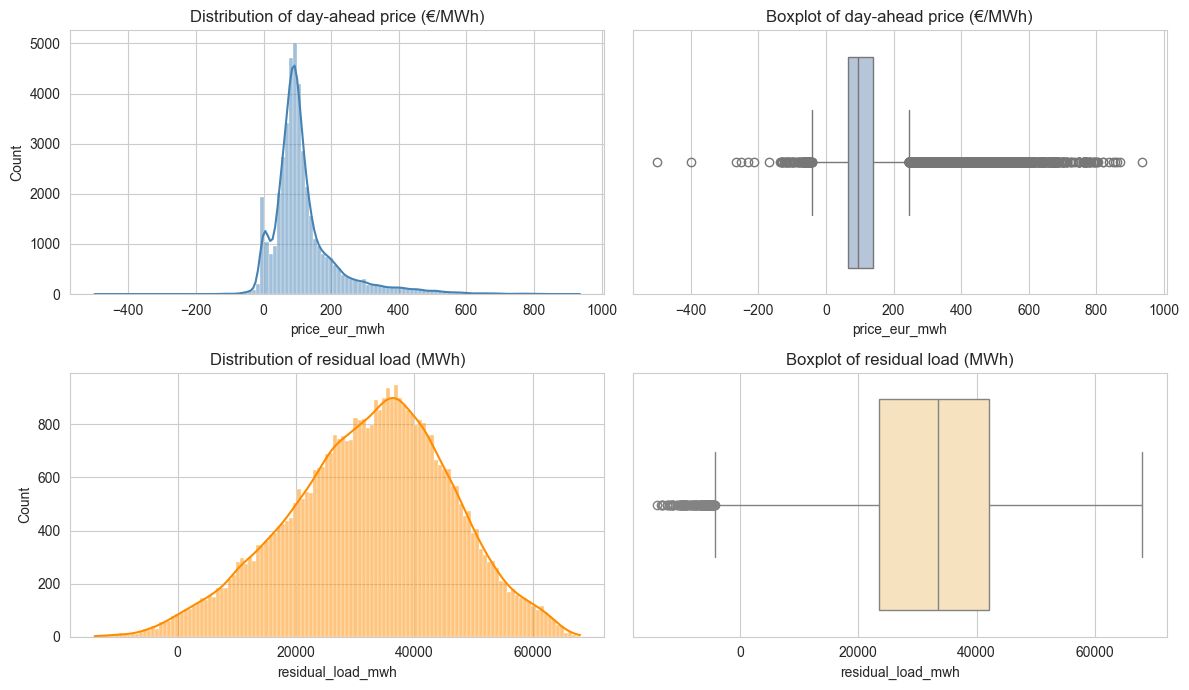

In [11]:
# -----------------------------
# 2.2.3 Distributions (price + residual load)
# -----------------------------
sns.set_style("whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(12, 7))

# Price distribution (hist)
sns.histplot(df["price_eur_mwh"], bins=120, kde=True, ax=axes[0, 0], color="steelblue")
axes[0, 0].set_title("Distribution of day-ahead price (€/MWh)")
axes[0, 0].set_xlabel("price_eur_mwh")

# Price boxplot (outliers)
sns.boxplot(x=df["price_eur_mwh"], ax=axes[0, 1], color="lightsteelblue")
axes[0, 1].set_title("Boxplot of day-ahead price (€/MWh)")
axes[0, 1].set_xlabel("price_eur_mwh")

# Residual load distribution (hist)
sns.histplot(df["residual_load_mwh"], bins=120, kde=True, ax=axes[1, 0], color="darkorange")
axes[1, 0].set_title("Distribution of residual load (MWh)")
axes[1, 0].set_xlabel("residual_load_mwh")

# Residual load boxplot
sns.boxplot(x=df["residual_load_mwh"], ax=axes[1, 1], color="moccasin")
axes[1, 1].set_title("Boxplot of residual load (MWh)")
axes[1, 1].set_xlabel("residual_load_mwh")

plt.tight_layout()
plt.show()

- Price distribution: strongly right-skewed with a long tail to very high prices; most hours cluster roughly around ~50–150 €/MWh, while a small share forms extreme spikes (visible in the boxplot as many right-side outliers).
- Negative prices: visible left tail below 0, consistent with the ~3.5% negative-hour count.
- Residual load: roughly unimodal around ~30–40k MWh, but with a left tail into negative values, indicating occasional hours where wind+solar exceed load; boxplot shows these as left-side outliers.

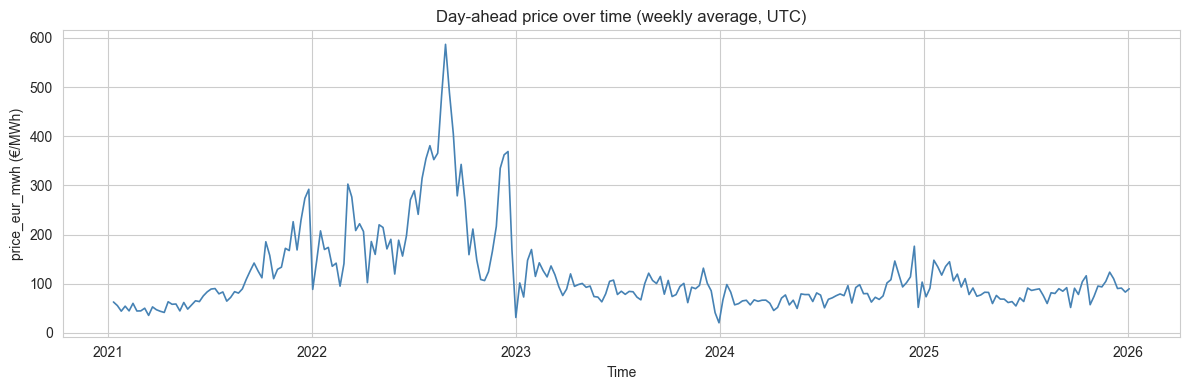

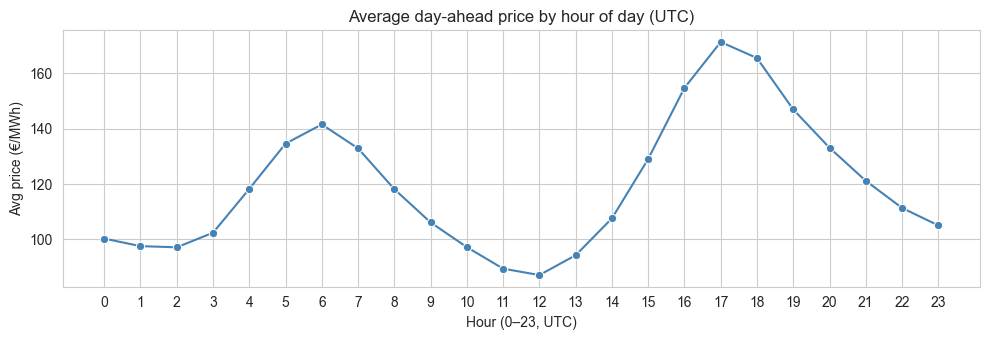

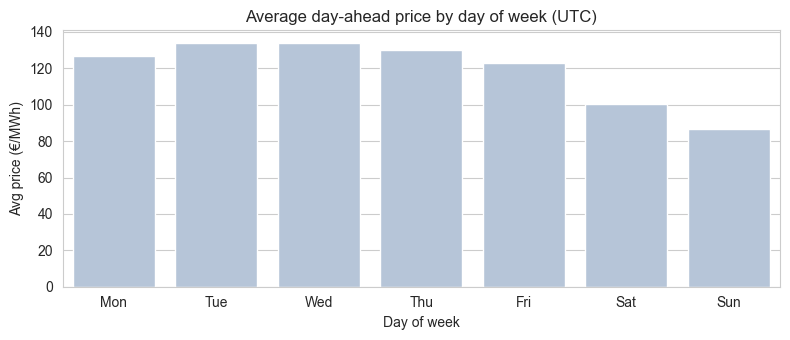

In [57]:
# -----------------------------
# 2.2.4 Time evolution + basic seasonality (hour/day patterns)
# -----------------------------
sns.set_style("whitegrid")

# Make a time-indexed view for resampling
dft = df.set_index("timestamp").sort_index()

# --- (A) Price over time: weekly mean (clean overview) ---
weekly = dft["price_eur_mwh"].resample("W").mean()

plt.figure(figsize=(12, 4))
plt.plot(weekly.index, weekly.values, linewidth=1.2, color="steelblue")
plt.title("Day-ahead price over time (weekly average, UTC)")
plt.xlabel("Time")
plt.ylabel("price_eur_mwh (€/MWh)")
plt.tight_layout()
plt.show()

# --- (B) Typical intraday pattern: avg price by hour-of-day ---
hourly_profile = df.groupby("hour")["price_eur_mwh"].mean().reset_index()

plt.figure(figsize=(10, 3.5))
sns.lineplot(data=hourly_profile, x="hour", y="price_eur_mwh", marker="o", color="steelblue")
plt.title("Average day-ahead price by hour of day (UTC)")
plt.xlabel("Hour (0–23, UTC)")
plt.ylabel("Avg price (€/MWh)")
plt.xticks(range(0, 24, 1))
plt.tight_layout()
plt.show()

# --- (C) Week pattern: avg price by day of week ---
dow_profile = df.groupby("day_of_week")["price_eur_mwh"].mean().reset_index()
dow_profile["day"] = dow_profile["day_of_week"].map({0:"Mon",1:"Tue",2:"Wed",3:"Thu",4:"Fri",5:"Sat",6:"Sun"})

plt.figure(figsize=(8, 3.5))
sns.barplot(data=dow_profile, x="day", y="price_eur_mwh", color="lightsteelblue")
plt.title("Average day-ahead price by day of week (UTC)")
plt.xlabel("Day of week")
plt.ylabel("Avg price (€/MWh)")
plt.tight_layout()
plt.show()

- The weekly average highlights a structural break around 2022 with strongly increased price levels and volatility, followed by a decline toward more moderate levels from 2023 onward.
- Prices show strong daily seasonality: peaks in the morning and late afternoon/evening, and lower prices around midday/night.
- Prices show weekly seasonality: weekdays are higher on average than weekends, with Sunday lowest.

#### 2.3 Investigate the relationships between different variables, especially how various factors such as weather conditions, demand, and significant events correlate with energy prices. Utilize statistical methods like Pearson’s or Spearman's rank correlation coefficient to quantify the strength and direction of these relationships.

,pearson_r,spearman_rho
day_of_week,-0.141,-0.161
hour,0.084,0.118
is_weekend,-0.162,-0.190
load_mwh,0.221,0.257
month,0.147,0.140
price_lag_168,0.763,0.683
price_lag_24,0.862,0.783
residual_load_lag_168,0.330,0.362
residual_load_lag_24,0.399,0.465
residual_load_mwh,0.565,0.693


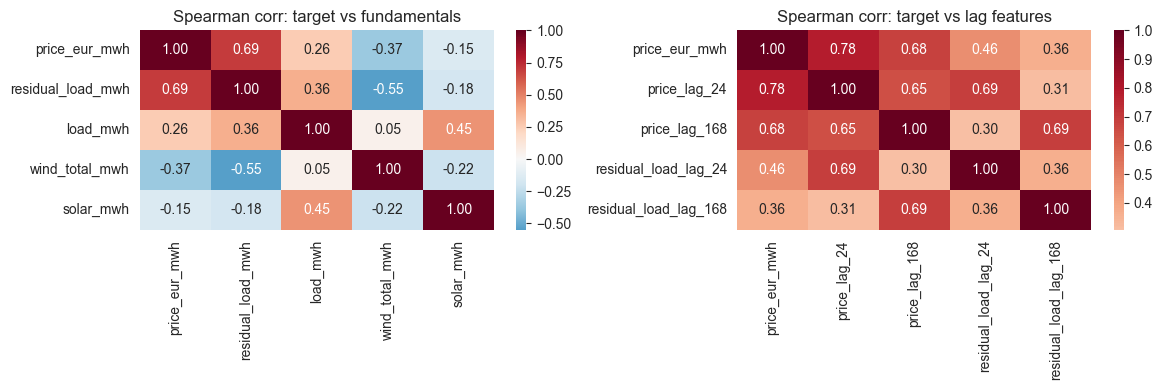

In [58]:
# -----------------------------
# 2.3.1 Correlations (Pearson + Spearman) + compact heatmaps
# -----------------------------
sns.set_style("whitegrid")

target = "price_eur_mwh"
vars_ = [
    "price_eur_mwh",
    "residual_load_mwh", "load_mwh", "wind_total_mwh", "solar_mwh",
    "price_lag_24", "price_lag_168",
    "residual_load_lag_24", "residual_load_lag_168",
    "hour", "day_of_week", "month", "is_weekend"
]

dfc = df[vars_].copy()

# --- Correlation tables: correlation with target (sorted by absolute value) ---
pearson = dfc.corr(method="pearson")[target].drop(target).sort_values(key=lambda s: s.abs(), ascending=False)
spearman = dfc.corr(method="spearman")[target].drop(target).sort_values(key=lambda s: s.abs(), ascending=False)

corr_table = pd.DataFrame({"pearson_r": pearson, "spearman_rho": spearman})
display(corr_table.style.format("{:.3f}"))

# --- Compact heatmaps (useful to show multicollinearity, esp. residual/load/wind/solar) ---
# Core fundamentals + target
core_vars = ["price_eur_mwh", "residual_load_mwh", "load_mwh", "wind_total_mwh", "solar_mwh"]
# Lags + target
lag_vars = ["price_eur_mwh", "price_lag_24", "price_lag_168", "residual_load_lag_24", "residual_load_lag_168"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(dfc[core_vars].corr(method="spearman"), annot=True, fmt=".2f",
            cmap="RdBu_r", center=0, ax=axes[0])
axes[0].set_title("Spearman corr: target vs fundamentals")

sns.heatmap(dfc[lag_vars].corr(method="spearman"), annot=True, fmt=".2f",
            cmap="RdBu_r", center=0, ax=axes[1])
axes[1].set_title("Spearman corr: target vs lag features")

plt.tight_layout()
plt.show()

- Strongest relationships are autoregressive: price_lag_24 (Pearson 0.862) and price_lag_168 (0.763) → strong daily/weekly persistence.
- Strong fundamental driver: residual_load_mwh (Spearman 0.693) → higher residual load tends to coincide with higher prices.
- Renewables relate negatively to price: wind_total_mwh (≈ −0.34 to −0.37) and solar_mwh (weak negative).
- Calendar effects exist but are smaller: is_weekend negative (lower prices on weekends), hour and month modest.

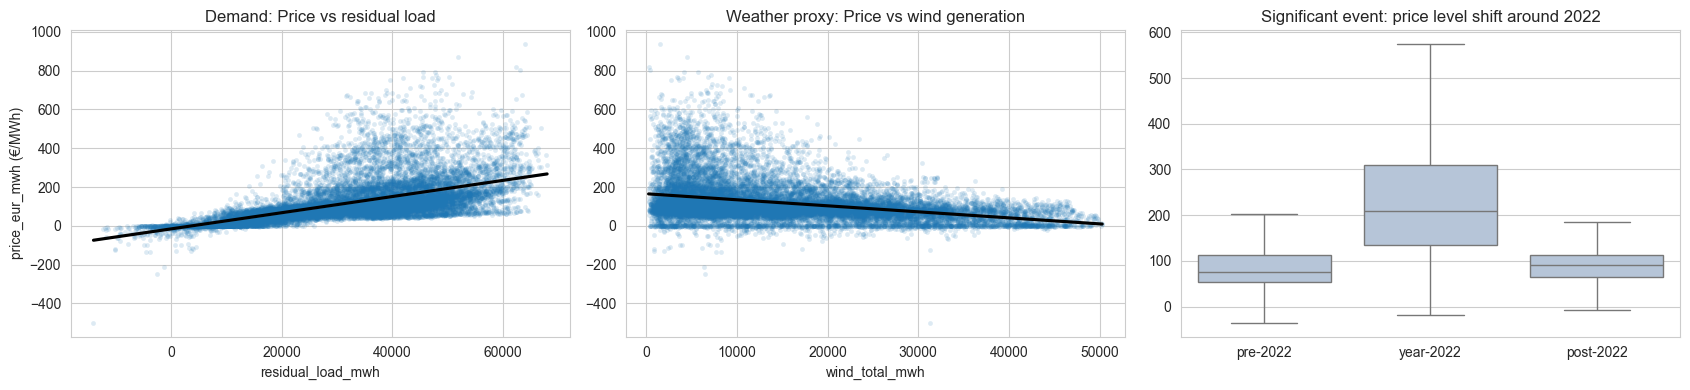

In [59]:
# -----------------------------
# 2.3.2 Relationships: demand, weather, and major event (2022)
# -----------------------------
sns.set_style("whitegrid")

# (A) Add a simple event-period indicator (war/energy crisis shock around 2022)
df_evt = df.copy()

t0 = pd.Timestamp("2022-01-01", tz="UTC")
t1 = pd.Timestamp("2023-01-01", tz="UTC")

df_evt["period"] = np.select(
    [
        df_evt["timestamp"] < t0,
        (df_evt["timestamp"] >= t0) & (df_evt["timestamp"] < t1),
        df_evt["timestamp"] >= t1,
    ],
    ["pre-2022", "year-2022", "post-2022"],
    default="unknown"  # must be string to avoid dtype errors
)

# Sample for scatter plots (readability + speed)
plot_df = df_evt.sample(n=min(20000, len(df_evt)), random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(17, 4))

# (1) Demand-side: price vs residual load
sns.scatterplot(
    data=plot_df, x="residual_load_mwh", y="price_eur_mwh",
    alpha=0.15, s=12, linewidth=0, ax=axes[0]
)
sns.regplot(
    data=plot_df, x="residual_load_mwh", y="price_eur_mwh",
    scatter=False, color="black", ax=axes[0]
)
axes[0].set_title("Demand: Price vs residual load")
axes[0].set_xlabel("residual_load_mwh")
axes[0].set_ylabel("price_eur_mwh (€/MWh)")

# (2) Weather proxy: price vs wind generation (forecast)
sns.scatterplot(
    data=plot_df, x="wind_total_mwh", y="price_eur_mwh",
    alpha=0.15, s=12, linewidth=0, ax=axes[1]
)
sns.regplot(
    data=plot_df, x="wind_total_mwh", y="price_eur_mwh",
    scatter=False, color="black", ax=axes[1]
)
axes[1].set_title("Weather proxy: Price vs wind generation")
axes[1].set_xlabel("wind_total_mwh")
axes[1].set_ylabel("")

# (3) Significant event: distribution shift across periods (hide outliers for readability)
sns.boxplot(
    data=df_evt[df_evt["period"] != "unknown"],
    x="period", y="price_eur_mwh",
    showfliers=False, color="lightsteelblue", ax=axes[2]
)
axes[2].set_title("Significant event: price level shift around 2022")
axes[2].set_xlabel("")
axes[2].set_ylabel("")

plt.tight_layout()
plt.show()

- Demand tightness (residual load): clear positive relationship—higher residual load is associated with higher prices. At high residual load the spread widens, suggesting higher volatility when the system is tight.
- Weather proxy (wind): clear negative relationship—higher forecast wind generation tends to lower prices, consistent with renewables pushing more expensive generation out of the merit order.
- Significant event (2022): the boxplot shows a strong level shift upward in 2022 (higher median and much wider whiskers), while pre-2022 and post-2022 are markedly lower and more stable.

<h2>Phase 3: Visualization &amp; Storytelling</h2>
<div style="position: relative;">
    <div style="position: absolute; top: -60px; right: 10px; padding: 5px; background-color: #ddd; border-radius: 5px; font-size: 20px; border: 1px solid black; text-align: right;">
        <span style="">&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; / 25</span>
    </div>
</div>

#### 3.1 Create visualizations that illustrate the historical trends in energy prices and highlight the key factors influencing price fluctuations.

In [27]:
# Libraries
import matplotlib.pyplot as plt

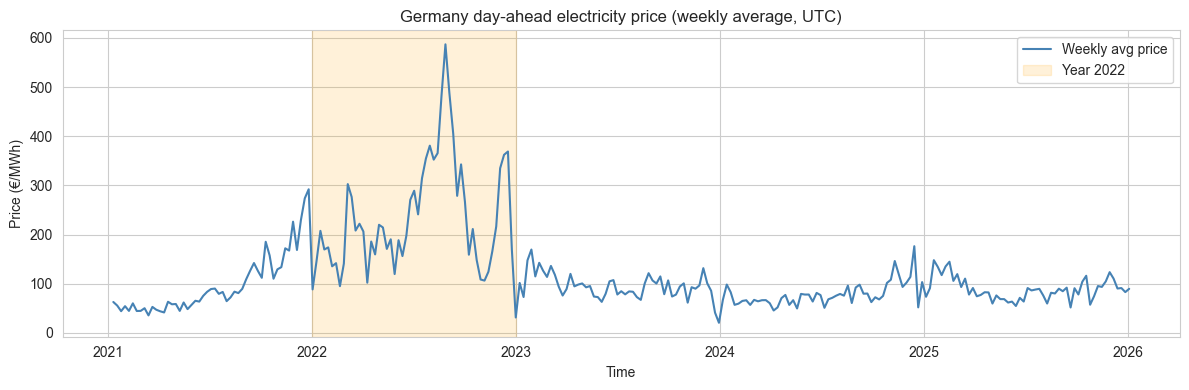

In [17]:
# -----------------------------
# 3.1 Historical price trend (weekly)
# -----------------------------
sns.set_style("whitegrid")

df = pd.read_csv("data/processed/features_smard_utc.csv", parse_dates=["timestamp"])
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
dft = df.set_index("timestamp").sort_index()

# Weekly averages for a clean long-run trend plot
weekly_price = dft["price_eur_mwh"].resample("W").mean()

plt.figure(figsize=(12, 4))
plt.plot(weekly_price.index, weekly_price.values, color="steelblue", linewidth=1.5, label="Weekly avg price")

# Highlight 2022 (structural break period)
plt.axvspan(pd.Timestamp("2022-01-01", tz="UTC"),
            pd.Timestamp("2023-01-01", tz="UTC"),
            color="orange", alpha=0.15, label="Year 2022")

plt.title("Germany day-ahead electricity price (weekly average, UTC)")
plt.xlabel("Time")
plt.ylabel("Price (€/MWh)")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

- Weekly prices are relatively stable in 2021, then rise sharply and become much more volatile during 2022 (highlighted), before falling back toward lower levels from 2023 onward.
- Outside the 2022 crisis period, weekly average prices mostly fluctuate in a comparatively narrower band, roughly around 50–120 €/MWh, with occasional temporary spikes.

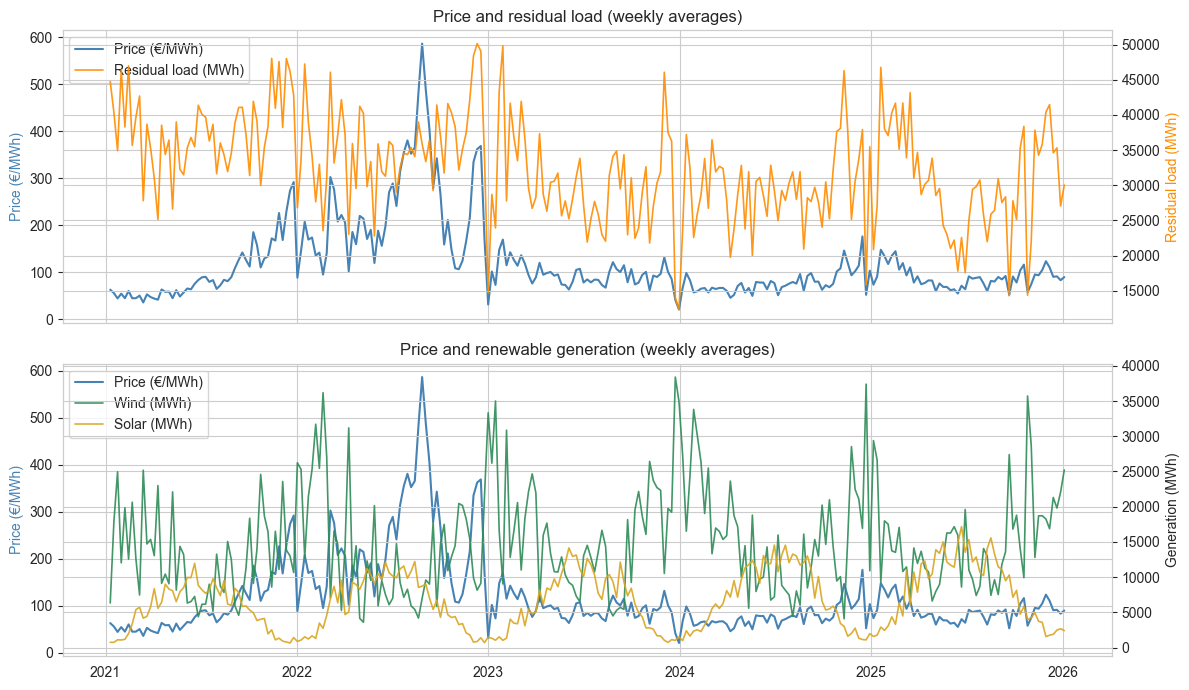

In [18]:
# -----------------------------
# 3.1 Key drivers (weekly): price vs residual load and renewables
# -----------------------------
sns.set_style("whitegrid")

df = pd.read_csv("data/processed/features_smard_utc.csv", parse_dates=["timestamp"])
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
dft = df.set_index("timestamp").sort_index()

weekly = dft.resample("W").mean(numeric_only=True)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# (A) Price and residual load (two y-axes, same time axis)
ax1 = axes[0]
ax2 = ax1.twinx()

ax1.plot(weekly.index, weekly["price_eur_mwh"], color="steelblue", linewidth=1.5, label="Price (€/MWh)")
ax2.plot(weekly.index, weekly["residual_load_mwh"], color="darkorange", linewidth=1.2, alpha=0.9, label="Residual load (MWh)")

ax1.set_title("Price and residual load (weekly averages)")
ax1.set_ylabel("Price (€/MWh)", color="steelblue")
ax2.set_ylabel("Residual load (MWh)", color="darkorange")

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

# (B) Price and renewable generation (wind+solar)
ax3 = axes[1]
ax4 = ax3.twinx()

ax3.plot(weekly.index, weekly["price_eur_mwh"], color="steelblue", linewidth=1.5, label="Price (€/MWh)")
ax4.plot(weekly.index, weekly["wind_total_mwh"], color="seagreen", linewidth=1.2, alpha=0.9, label="Wind (MWh)")
ax4.plot(weekly.index, weekly["solar_mwh"], color="goldenrod", linewidth=1.2, alpha=0.9, label="Solar (MWh)")

ax3.set_title("Price and renewable generation (weekly averages)")
ax3.set_ylabel("Price (€/MWh)", color="steelblue")
ax4.set_ylabel("Generation (MWh)")

lines3, labels3 = ax3.get_legend_handles_labels()
lines4, labels4 = ax4.get_legend_handles_labels()
ax3.legend(lines3 + lines4, labels3 + labels4, loc="upper left")

plt.xlabel("Time")
plt.tight_layout()
plt.show()

- Price and residual load tend to move together: higher residual load (tighter system) often coincides with higher weekly prices.
- Higher renewable generation—especially wind—often lines up with lower prices, consistent with renewables reducing the need for expensive marginal generation.
- Solar shows strong seasonal swings (summer higher than winter), which contributes to seasonal variation in residual load and price levels.

#### 3.2 Use graphs to compare actual vs. predicted energy prices to evaluate the model's performance visually.

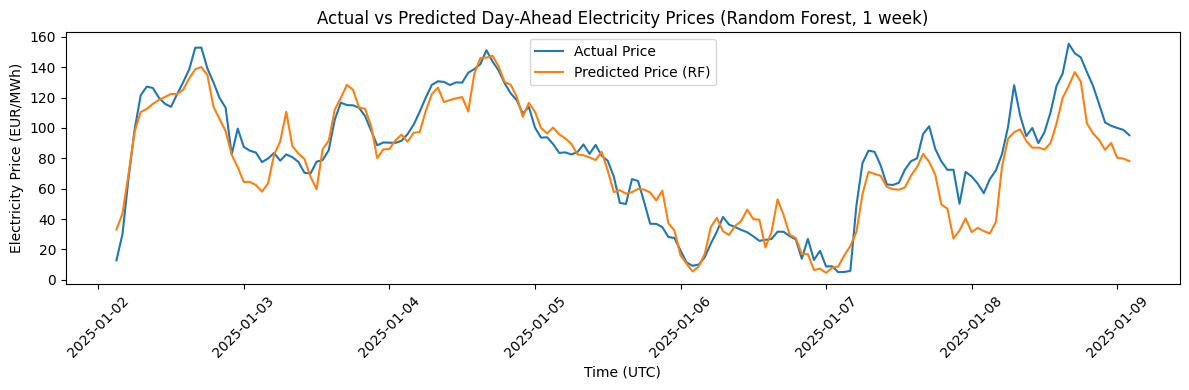

In [28]:
# ------------------------------------------------------------
# 3.2 Actual vs Predicted Electricity Prices (Random Forest)
# ------------------------------------------------------------

# Recreate plotting DataFrame WITH timestamp aligned to X_test indices
plot_df = pd.DataFrame({
    "timestamp": df.loc[X_test.index, "timestamp"].values,
    "Actual Price": y_test.values,
    "Predicted Price": y_pred_rf
}).sort_values("timestamp")

# Select a continuous one-week period from the test set (168 hours)
start_time = plot_df["timestamp"].min()
end_time = start_time + pd.Timedelta(hours=168)
plot_df_week = plot_df[(plot_df["timestamp"] >= start_time) & (plot_df["timestamp"] < end_time)]

plt.figure(figsize=(12, 4))
plt.plot(plot_df_week["timestamp"], plot_df_week["Actual Price"], label="Actual Price", linewidth=1.5)
plt.plot(plot_df_week["timestamp"], plot_df_week["Predicted Price"], label="Predicted Price (RF)", linewidth=1.5)

plt.xlabel("Time (UTC)")
plt.ylabel("Electricity Price (EUR/MWh)")
plt.title("Actual vs Predicted Day-Ahead Electricity Prices (Random Forest, 1 week)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

- The Random Forest forecast follows the main ups and downs over the selected week and captures the overall daily pattern reasonably well. Larger deviations appear around sharper local peaks and turning points, where the model tends to smooth the extremes. Overall, the plot supports the metric results: good typical accuracy, with remaining difficulty during sudden changes.

#### 3.3 Explain your findings by connecting the dots between visuals, forecasts, and insights, making it easier to understand how energy prices change and what that means for people and businesses.

- The figures show that German day-ahead prices move in clear patterns: they repeat over the day, differ between weekdays and weekends, and change with the season. At the same time, the long-term weekly plot makes it obvious that the general price level is not stable across years. The year 2022 stands out with much higher prices and much stronger volatility than 2021 and most of 2023–2025.
- Looking at the “actual vs predicted” plot helps to judge the model in a way that MAE and RMSE alone cannot. Over the example week, the Random Forest prediction follows the overall ups and downs quite well, so it often gets the timing of increases and decreases right. But the prediction is smoother than the real curve. The largest gaps appear around sharper peaks and quick turning points, where the model tends to underestimate how strong the movement is.
- For people and businesses, this means forecasts are useful to get a sense of the general trend and the daily pattern (when prices are likely to be higher or lower). But they are less reliable for exact price levels in hours with sudden market changes. In practice, this is where additional caution is needed, for example by keeping buffers, using hedging, or relying on flexibility options because the most expensive (or most unusual) hours are the hardest to predict.

<h2>Phase 4: Predictive Modeling</h2>
<div style="position: relative;">
    <div style="position: absolute; top: -60px; right: 10px; padding: 5px; background-color: #ddd; border-radius: 5px; font-size: 20px; border: 1px solid black; text-align: right;">
        <span style="">&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; / 25</span>
    </div>
</div>

#### 4.1 Develop predictive models to forecast average hourly energy prices on January 27, 2026. Consider following modeling techniques. Evaluate different models based on reasonable performance metrics (e.g. RMSE, MAE) to select the best-performing model.:

- Linear Regression
- Time Series Analysis (e.g. ARIMA)
- Machine Learning models (e.g. Random Forest, Neural Networks)

In [22]:
# Libraries
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.ensemble import RandomForestRegressor

In [9]:
# -----------------------------
# Load dataset (processed path) + define target/features
# -----------------------------
df = pd.read_csv("data/processed/features_smard_utc.csv", parse_dates=["timestamp"])
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)

# Target
y = df["price_eur_mwh"]

# Features (keep her selected set)
feature_cols = [
    "price_lag_24",
    "price_lag_168",
    "residual_load_mwh",
    "residual_load_lag_24",
    "residual_load_lag_168",
    "hour",
    "day_of_week",
    "month",
    "is_weekend",
]
X = df[feature_cols]

df.head()

,timestamp,price_eur_mwh,load_mwh,wind_offshore_mwh,wind_onshore_mwh,wind_total_mwh,solar_mwh,residual_load_mwh,price_lag_24,price_lag_168,residual_load_lag_24,residual_load_lag_168,hour,day_of_week,month,is_weekend
0,2021-01-07 23:00:00+00:00,50.53,48253.25,1052.50,6426.00,7478.50,0.0,40774.75,51.03,50.87,39975.25,38522.75,23,3,1,0
1,2021-01-08 00:00:00+00:00,48.43,46315.75,1141.75,6333.50,7475.25,0.0,38840.50,50.18,48.19,37906.75,37480.75,0,4,1,0
2,2021-01-08 01:00:00+00:00,47.24,45664.25,1161.25,6258.50,7419.75,0.0,38244.50,48.97,44.68,37313.75,36869.50,1,4,1,0
3,2021-01-08 02:00:00+00:00,45.61,46053.25,1204.00,6212.25,7416.25,0.0,38637.00,46.72,42.92,37469.75,36882.00,2,4,1,0
4,2021-01-08 03:00:00+00:00,46.81,47048.75,1290.00,6122.00,7412.00,0.0,39636.75,46.87,40.39,38704.00,36852.75,3,4,1,0


In [12]:
# ------------------------------------------------------------
# Structural break handling: add an "era" feature (pre / 2022 / post)
# ------------------------------------------------------------
t0 = pd.Timestamp("2022-01-01", tz="UTC")
t1 = pd.Timestamp("2023-01-01", tz="UTC")

df["era"] = np.select(
    [
        df["timestamp"] < t0,
        (df["timestamp"] >= t0) & (df["timestamp"] < t1),
        df["timestamp"] >= t1,
    ],
    ["pre", "crisis_2022", "post"],
    default="post"
)

# Add era to the feature matrix and one-hot encode for linear models
X = df[feature_cols + ["era"]]
X = pd.get_dummies(X, columns=["era"], drop_first=True)

# Optional: confirm the new columns exist
print("Feature columns now include:", [c for c in X.columns if c.startswith("era_")])

Feature columns now include: ['era_post', 'era_pre']


In [13]:
# ------------------------------------------------------------
# Baseline model: Seasonal naive forecast (lag 24)
# ------------------------------------------------------------

# Use only rows where the baseline prediction exists
mask = df["price_lag_24"].notna() & df["price_eur_mwh"].notna()
y_true = df.loc[mask, "price_eur_mwh"]
y_pred = df.loc[mask, "price_lag_24"]

mae_baseline = mean_absolute_error(y_true, y_pred)
rmse_baseline = np.sqrt(mean_squared_error(y_true, y_pred))

print("Baseline model results:")
print("MAE:", mae_baseline)
print("RMSE:", rmse_baseline)

Baseline model results:
MAE: 32.97836563129925
RMSE: 52.9406617195734


- As a simple benchmark, we predict the electricity price using the price from the same hour on the previous day (lag 24). This model serves as a reference to evaluate more complex models.

In [16]:
# ------------------------------------------------------------
# Linear Regression model (time-based train/test split)
# ------------------------------------------------------------

# Drop any remaining NaNs in X/y
data_lr = pd.concat([df[["timestamp"]], X, y], axis=1).dropna().sort_values("timestamp")

X_lr = data_lr.drop(columns=["timestamp", "price_eur_mwh"])
y_lr = data_lr["price_eur_mwh"]

# Time-based split: first 80% train, last 20% test
split_idx = int(len(data_lr) * 0.8)
X_train = X_lr.iloc[:split_idx]
X_test  = X_lr.iloc[split_idx:]
y_train = y_lr.iloc[:split_idx]
y_test  = y_lr.iloc[split_idx:]

# Train + predict
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

# Metrics
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print("Linear Regression results (time split):")
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)

Linear Regression results (time split):
MAE: 17.276555776162873
RMSE: 24.219543842881738


In [21]:
# ------------------------------------------------------------
# SARIMAX (ARIMA with exogenous regressors)
# ------------------------------------------------------------
data_smx = pd.concat([df[["timestamp"]], X, y], axis=1).dropna().sort_values("timestamp")
data_smx = data_smx.set_index("timestamp").asfreq("h")

y_smx = data_smx["price_eur_mwh"]
X_smx = data_smx.drop(columns=["price_eur_mwh"])

# Ensure all exogenous columns are numeric
X_smx = X_smx.apply(pd.to_numeric, errors="coerce").astype(float)

# Drop any rows made NaN by coercion
valid = X_smx.notna().all(axis=1) & y_smx.notna()
y_smx = y_smx.loc[valid]
X_smx = X_smx.loc[valid]

split_idx = int(len(y_smx) * 0.8)
y_train_smx, y_test_smx = y_smx.iloc[:split_idx], y_smx.iloc[split_idx:]
X_train_smx, X_test_smx = X_smx.iloc[:split_idx], X_smx.iloc[split_idx:]

smx_model = SARIMAX(
    y_train_smx,
    exog=X_train_smx,
    order=(1, 0, 1),
    enforce_stationarity=False,
    enforce_invertibility=False
)
smx_res = smx_model.fit(disp=False)

forecast_smx = smx_res.forecast(steps=len(y_test_smx), exog=X_test_smx)

mae_smx = mean_absolute_error(y_test_smx, forecast_smx)
rmse_smx = np.sqrt(mean_squared_error(y_test_smx, forecast_smx))

print("SARIMAX(1,0,1) + exog results:")
print("MAE:", mae_smx)
print("RMSE:", rmse_smx)

SARIMAX(1,0,1) + exog results:
MAE: 19.775426595414537
RMSE: 26.29967989070319


- We used SARIMAX instead of a univariate ARIMA because electricity prices are strongly driven by exogenous fundamentals (load, wind/solar, residual load) and the 2022 regime shift; SARIMAX can incorporate these predictors directly, while ARIMA models prices using past prices alone.

In [23]:
# ------------------------------------------------------------
# Random Forest Regression model (time-based split)
# ------------------------------------------------------------
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("Random Forest results (time split):")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)

# ------------------------------------------------------------
# Final comparison table
# ------------------------------------------------------------
results = pd.DataFrame({
    "Model": ["Baseline (lag-24)", "Linear Regression", "Random Forest", "SARIMAX(1,0,1)+exog"],
    "MAE":   [mae_baseline,        mae_lr,             mae_rf,          mae_smx],
    "RMSE":  [rmse_baseline,       rmse_lr,            rmse_rf,         rmse_smx],
}).sort_values("RMSE")

results

Random Forest results (time split):
MAE: 13.883801591846083
RMSE: 25.01517888503849


,Model,MAE,RMSE
1,Linear Regression,17.276556,24.219544
2,Random Forest,13.883802,25.015179
3,"SARIMAX(1,0,1)+exog",19.775427,26.299680
0,Baseline (lag-24),32.978366,52.940662


- With the added era feature (pre / 2022 / post), all feature-based models improve and remain clearly better than the seasonal naïve baseline. Random Forest achieves the lowest MAE, meaning it is best on typical hours, while Linear Regression has the lowest RMSE, indicating fewer large errors on extreme hours. SARIMAX(+exog) performs worse than both LR and RF here, suggesting that a simple linear or tree-based approach captures the relationships in this dataset more effectively.

- We select Random Forest as the final model because it minimizes MAE (best average accuracy), while Linear Regression remains a strong and more interpretable alternative.

In [33]:
# ------------------------------------------------------------
# Train final Random Forest using day-ahead-available features only
# (No price lags / no residual-load lags, since 2026 history is not included)
# ------------------------------------------------------------

# Day-ahead feature set: forecasts + calendar + derived residual load
feature_cols_da = [
    "load_mwh",
    "wind_offshore_mwh",
    "wind_onshore_mwh",
    "solar_mwh",
    "residual_load_mwh",
    "hour",
    "day_of_week",
    "month",
    "is_weekend",
]

# Recreate era feature (structural break handling)
t0 = pd.Timestamp("2022-01-01", tz="UTC")
t1 = pd.Timestamp("2023-01-01", tz="UTC")

df_da = df.copy()
df_da["era"] = np.select(
    [
        df_da["timestamp"] < t0,
        (df_da["timestamp"] >= t0) & (df_da["timestamp"] < t1),
        df_da["timestamp"] >= t1,
    ],
    ["pre", "crisis_2022", "post"],
    default="post"
)

# Build X/y and one-hot encode era
X_da = df_da[feature_cols_da + ["era"]]
X_da = pd.get_dummies(X_da, columns=["era"], drop_first=True)
y_da = df_da["price_eur_mwh"]

# Drop missing
data_full_da = pd.concat([df_da[["timestamp"]], X_da, y_da], axis=1).dropna().sort_values("timestamp")
X_final_da = data_full_da.drop(columns=["timestamp", "price_eur_mwh"])
y_final_da = data_full_da["price_eur_mwh"]

# Train final model on all available history (2021–2025)
final_model_da = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)
final_model_da.fit(X_final_da, y_final_da)

print("Final day-ahead model trained on:", X_final_da.shape[0], "rows and", X_final_da.shape[1], "features.")
print("Era dummy columns:", [c for c in X_final_da.columns if c.startswith("era_")])

Final day-ahead model trained on: 43656 rows and 11 features.
Era dummy columns: ['era_post', 'era_pre']


In [36]:
# ------------------------------------------------------------
# Build Jan 27-like features from historical patterns
# ------------------------------------------------------------

# Work on a copy with needed columns
sc = df.copy()
sc["timestamp"] = pd.to_datetime(sc["timestamp"], utc=True)

# Define target forecast date (UTC hours 0–23)
forecast_date = pd.Timestamp("2026-01-27", tz="UTC")
ts_2026 = pd.date_range(forecast_date, periods=24, freq="h")

# Choose reference set: January Tuesdays in the post-2022 period
# (Jan 27, 2026 is a Tuesday)
ref = sc[
    (sc["timestamp"] >= pd.Timestamp("2023-01-01", tz="UTC")) &
    (sc["timestamp"].dt.month == 1) &
    (sc["timestamp"].dt.dayofweek == 1)  # Tuesday
].copy()

# Hourly averages for the day-ahead-available fundamentals
fund_cols = ["load_mwh", "wind_offshore_mwh", "wind_onshore_mwh", "solar_mwh"]
hourly_means = ref.groupby(ref["timestamp"].dt.hour)[fund_cols].mean()

# Assemble 24-hour scenario features
X_2026 = pd.DataFrame(index=ts_2026)
X_2026["hour"] = X_2026.index.hour
X_2026["day_of_week"] = X_2026.index.dayofweek
X_2026["month"] = X_2026.index.month
X_2026["is_weekend"] = (X_2026["day_of_week"] >= 5).astype(int)

# Map hourly means into the forecast day
for c in fund_cols:
    X_2026[c] = X_2026["hour"].map(hourly_means[c])

# Derived feature
X_2026["residual_load_mwh"] = X_2026["load_mwh"] - (
    X_2026["wind_offshore_mwh"] + X_2026["wind_onshore_mwh"] + X_2026["solar_mwh"]
)

# Era dummies must match training
X_2026["era_post"] = 1
X_2026["era_pre"] = 0

# Ensure column order matches training matrix
X_2026 = X_2026[X_final_da.columns]

# Predict 24 hourly prices
yhat_2026 = final_model_da.predict(X_2026)

pred_2026 = pd.DataFrame({
    "timestamp": ts_2026,
    "pred_price_eur_mwh": yhat_2026
})

pred_2026

,timestamp,pred_price_eur_mwh
0,2026-01-27 00:00:00+00:00,78.291567
1,2026-01-27 01:00:00+00:00,71.891600
2,2026-01-27 02:00:00+00:00,71.044733
3,2026-01-27 03:00:00+00:00,79.410300
4,2026-01-27 04:00:00+00:00,88.875500
5,2026-01-27 05:00:00+00:00,95.436367
6,2026-01-27 06:00:00+00:00,127.624300
7,2026-01-27 07:00:00+00:00,146.207633
8,2026-01-27 08:00:00+00:00,140.104333
9,2026-01-27 09:00:00+00:00,113.398533


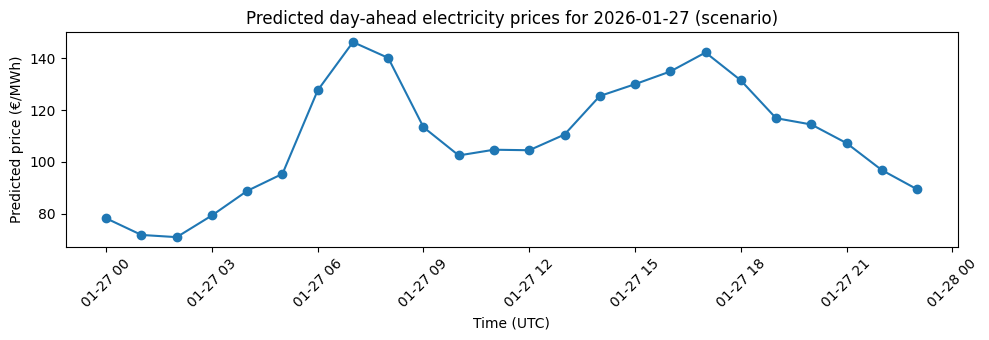

In [38]:
# ------------------------------------------------------------
# Final predicted prices for 2026-01-27 (scenario forecast)
# ------------------------------------------------------------
plt.figure(figsize=(10, 3.5))
plt.plot(pred_2026["timestamp"], pred_2026["pred_price_eur_mwh"], marker="o", linewidth=1.5)

plt.title("Predicted day-ahead electricity prices for 2026-01-27 (scenario)")
plt.xlabel("Time (UTC)")
plt.ylabel("Predicted price (€/MWh)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

- These are a scenario-based day-ahead forecast, because SMARD did not provide official load/wind/solar forecasts for 2026-01-27 at export time (“No data for submitted query”). We therefore approximated the fundamentals using average hourly patterns of January Tuesdays in the post-2022 period. The predicted profile shows a typical weekday shape with higher prices in the morning/late afternoon and lower prices overnight/midday.  


*<small>
AI/LLM use disclaimer: We used a large language model as a support tool for debugging code, improving notebook structure, and clarifying workflow. All data processing, modeling decisions, results, and interpretations were implemented and reviewed by the authors.
</small>*

In [40]:
!jupyter nbconvert --to webpdf --allow-chromium-download 2025_ds1_project_report_group17.ipynb

[NbConvertApp] Converting notebook 2025_ds1_project_report_group17.ipynb to webpdf
[NbConvertApp] WARNING | Alternative text is missing on 10 image(s).
[NbConvertApp] Building PDF
[NbConvertApp] PDF successfully created
[NbConvertApp] Writing 1136336 bytes to 2025_ds1_project_report_group17.pdf
